In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

import numpy as np 
import h5ify 
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import importlib
import json

import sys
sys.path.append('/home/kgk3/tdinf/tdinf/')
from tdinf import group_postprocess, utils, run_sampler, waveform_h5s

importlib.reload(group_postprocess)
importlib.reload(run_sampler)

import scipy.linalg as sl

from matplotlib.lines import Line2D
import seaborn as sns
sns.set_palette('colorblind')

### Load likelihood manager

In [21]:
 # Get likelihood manager
# run = 'output'
# data = group_postprocess.load_run_settings_from_directory(
#     'output/'+run,
data = group_postprocess.load_run_settings_from_directory('output_GW241110_260706_ST4_20k_-0p1_-0p05_-0p025_0', filename_dict={'full':'full_0.0seconds'})
lm = data['runs']['full']['likelihood_manager']

/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"


### Load FD posterior and get maxL reconstruction

In [22]:
# get reference parameters
FD_posterior = h5ify.load('GW241110_input_data/GW241110_124123-combined_PEDataRelease.h5')['C00:SEOBNRv5PHM']['posterior_samples']

# get maxL
imax = np.argmax(FD_posterior['log_likelihood'])
reference_parameters_ = FD_posterior[imax]
reference_parameters = {k: reference_parameters_[k] for k in reference_parameters_.dtype.names}

In [23]:
# Get injection
reference_parameters_transformed = run_sampler.modify_parameters(reference_parameters, data['runs']['full']['args'])
injection_dict = lm.waveform_manager.get_projected_waveform(
    reference_parameters_transformed,
    lm.ifos,
    lm.time_dict,
    lm.f22_start, 
    lm.f_ref
)
# Whiten injection
injection_dict_whitened = {ifo : utils.whitenData(
    injection_dict[ifo], 
    lm.time_dict[ifo],
    lm.conditioned_psd_dict[ifo][:, 1], 
    lm.conditioned_psd_dict[ifo][:, 0]
) for ifo in lm.ifos}

In [24]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    data['runs']['full']['kwargs']['right_ascension'], 
    data['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

### Cumulative SNR check

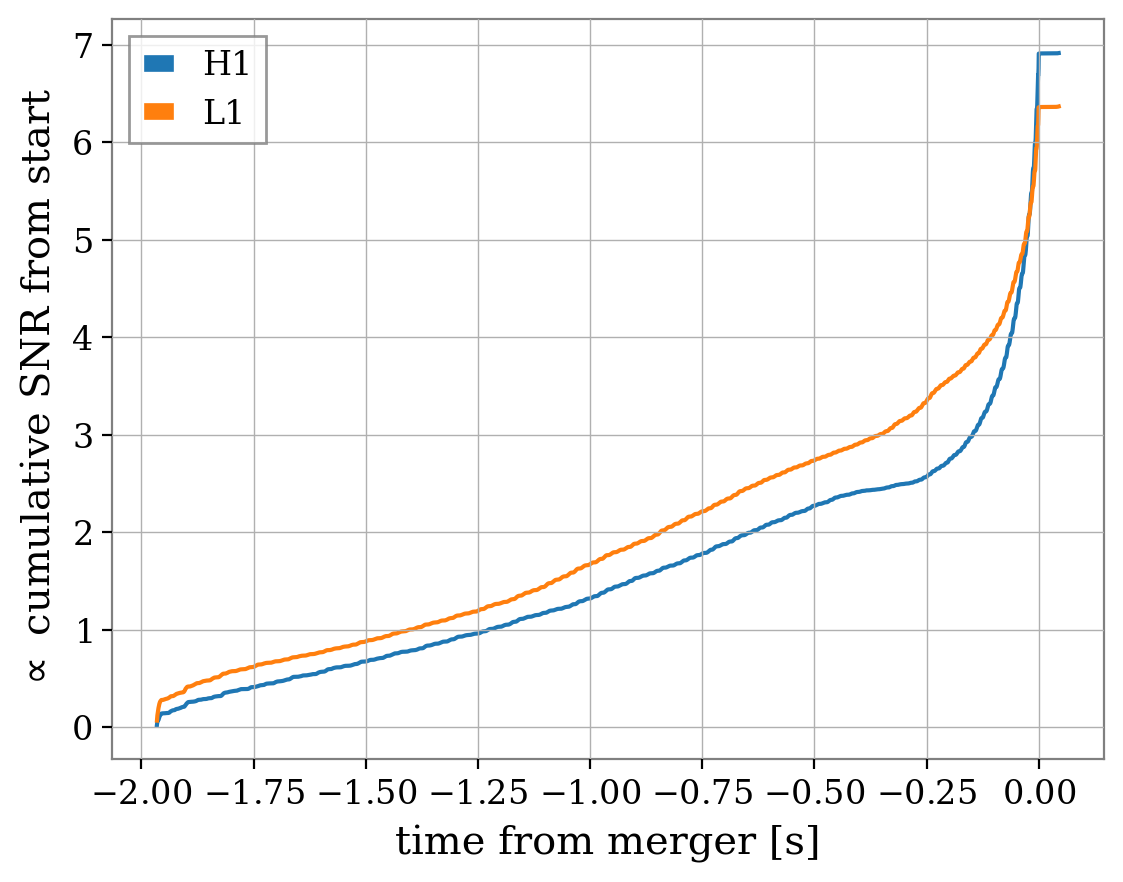

In [25]:
plt.plot()
for ifo in lm.ifos:
    
    times_det = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]
    cum_snr = np.sqrt(np.cumsum(injection_dict_whitened[ifo]**2))
    
    plt.plot(times_det, cum_snr, label=ifo)

plt.legend()
plt.ylabel('$\propto$ cumulative SNR from start')
plt.xlabel('time from merger [s]')
plt.show()

In [26]:
times_det_H = lm.time_dict[lm.ifos[0]] - lm.reference_time - dt_dict[lm.ifos[0]]
times_det_L = lm.time_dict[lm.ifos[1]] - lm.reference_time - dt_dict[lm.ifos[1]]

In [27]:
cum_snr_L=np.interp(times_det_H, times_det_L, np.sqrt(np.cumsum(injection_dict_whitened[lm.ifos[1]]**2)))

In [28]:
# calculate the cumulative network SNR
cum_nsnr = np.sqrt((np.sqrt(np.cumsum(injection_dict_whitened[lm.ifos[0]]**2)))**2 + (cum_snr_L)**2)

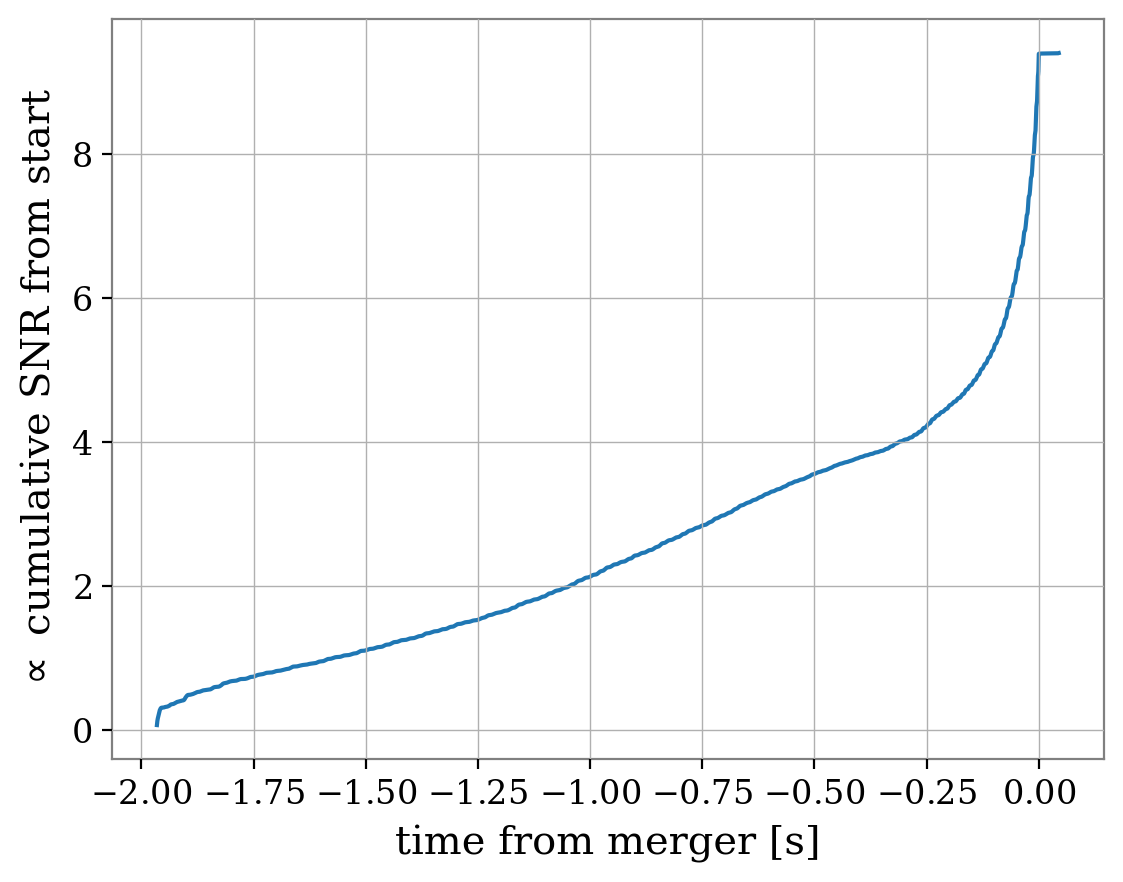

In [29]:
plt.plot(times_det_H, cum_nsnr, label='SNR')
plt.ylabel('$\propto$ cumulative SNR from start')
plt.xlabel('time from merger [s]')
plt.show()

In [30]:
print(max(cum_nsnr))
print(min(cum_nsnr))
snrs = np.linspace(min(cum_nsnr), max(cum_nsnr), num=10)
print(snrs)

9.401583686948456
0.0712700722226851
[0.07127007 1.10797158 2.1446731  3.18137461 4.21807612
 5.25477764 6.29147915 7.32818066 8.36488217 9.40158369]


In [31]:
times = np.interp(snrs, cum_nsnr, times_det_H)
print(times)

[-1.96535884 -1.50039116 -0.9965537  -0.6401301  -0.25027933
 -0.10496729 -0.05129944 -0.02343166 -0.00707833  0.04440678]


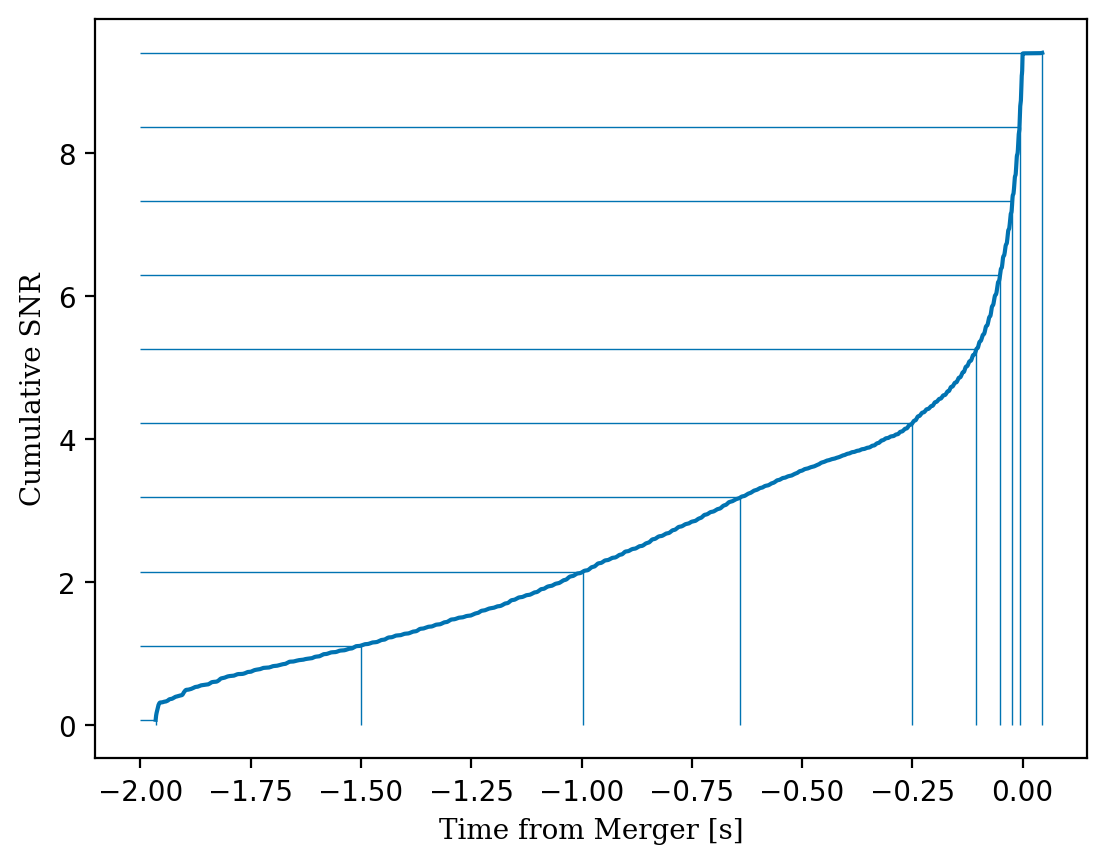

In [47]:
plt.plot(times_det_H, cum_nsnr)
plt.rcParams['font.family'] = 'serif'
for p, t in zip(snrs, times):
    plt.hlines(p, -2, t, linewidth= 0.5)
    plt.vlines(t, 0, p, linewidth= 0.5)
plt.grid(False)
plt.ylabel('Cumulative SNR', fontfamily='serif')
plt.xlabel('Time from Merger [s]', fontfamily='serif')
plt.show()

In [33]:
# Get whitened strain 
data_dict_wh =  utils.whitenData_dict_TD(lm.data_dict, lm)

In [34]:
# Load waveform reconstructions from the full run
wfs_full = waveform_h5s.load_waveform_h5py(f'output_GW241110_260706_ST4_20k_-0p1_-0p05_-0p025_0/waveforms/full_waveforms.h5')

In [35]:
# Whiten waveform reconstructions
L_dict= {} # first, make a Cholesky decomposition of the Toeplitz matrix from the ACF for quick whitening
for ifo in lm.ifos:
    C = sl.toeplitz(lm.rho_dict[ifo])
    L_dict[ifo] = sl.cholesky(C,lower=True)
    
wfs_full_whitened = utils.whiten_wfs_TD(wfs_full['samples'], L_dict)

100%|███████████████████████████████████████████████████████████| 1000/1000 [01:22<00:00, 12.09it/s]


In [36]:
# Load in the result
result = group_postprocess.load_run_settings_from_directory('output_GW241110_260706_ST4_20k_-0p1_-0p05_-0p025_0')

/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"
/home/kgk3/tdinf/tdinf/utils/likelihood.py:508: UserWarning: --waveform-kwargs is only supported for gwsignal approximants;ignoring for SpinTaylorT4 which uses the lal interface
  warnings.warn(f"--waveform-kwargs is only supported for gwsignal approximants;"


In [37]:
# Get detector delay times 
dt_dict = lm.waveform_manager.antenna_and_time_manager.compute_time_delay_dict(
    result['runs']['full']['kwargs']['right_ascension'], 
    result['runs']['full']['kwargs']['declination'], 
    lm.reference_time, 
    lm.ifos
)

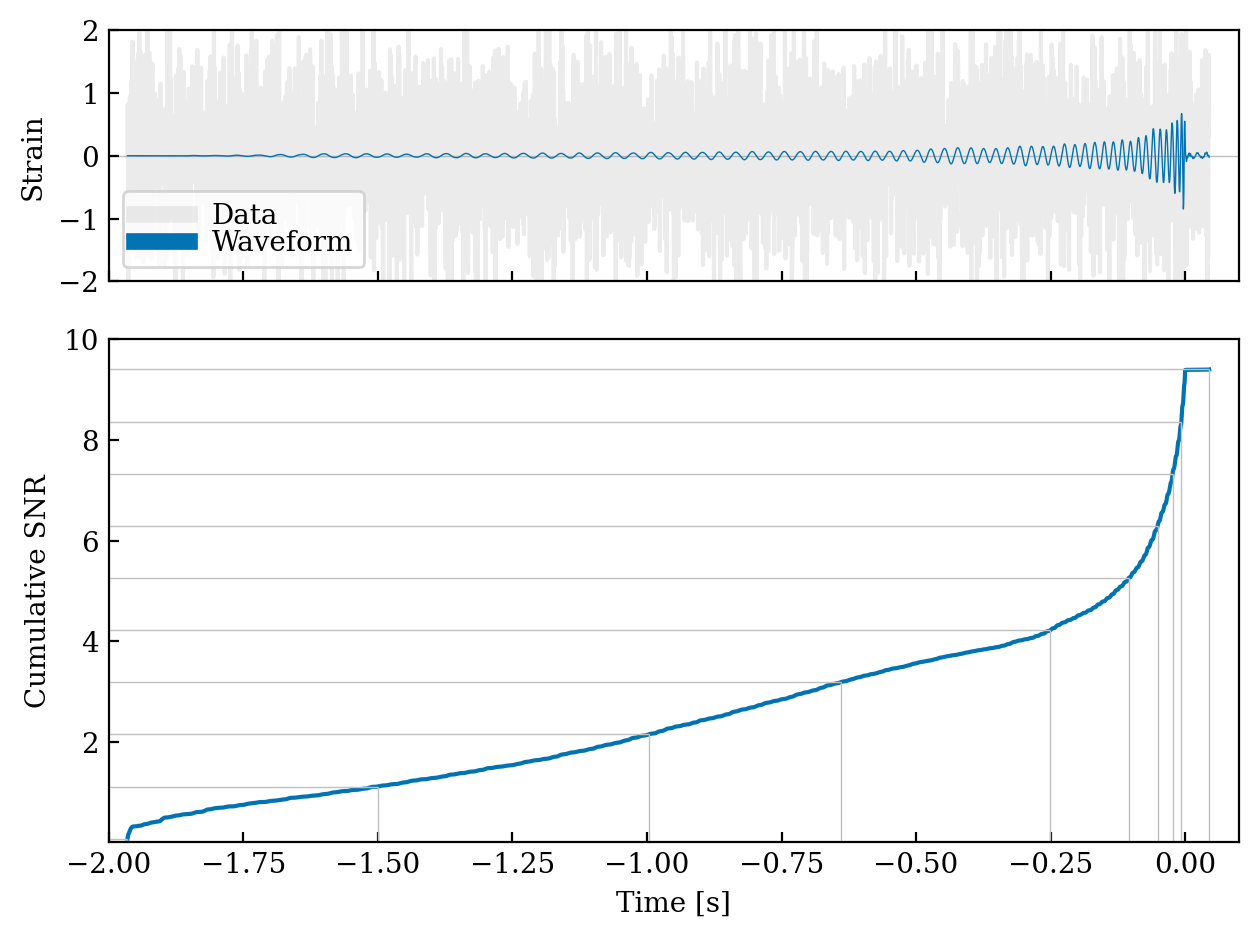

In [51]:
fig, axes = plt.subplots(2, 1, sharex=True, height_ratios=[1,2])

time_from_merger = lm.time_dict[ifo] - lm.reference_time - dt_dict[ifo]

axes[0].plot(time_from_merger, data_dict_wh['H1'], color='silver', zorder=0, alpha=0.3, label='Data')
median_waveform = np.median([wfs_full_whitened[j]['H1'] for j in range(len(wfs_full_whitened))], axis=0)
axes[0].plot(time_from_merger, median_waveform, color='C0', lw=0.5, alpha=1, zorder=2, label='Waveform')
# for j in range(len(wfs_full['samples'])):
#     axes[0].plot(time_from_merger, wfs_full_whitened[j]['H1'], color='C0', lw=0.5, alpha=0.01, zorder=2)
# handles = [Line2D([], [], color='silver', label='strain'), Line2D([], [], color='C0', label='reconstructions')]
axes[0].legend(loc='lower left', fontsize=10, labelspacing=0)
axes[0].set_xlim(-2, 0.1)
axes[0].set_ylim(-2, 2)
axes[0].set_ylabel('Strain')
axes[0].hlines(0, -2, 0.1, linewidth=0.5, color='gray', alpha=0.5, zorder=1)
axes[0].tick_params(axis='both', direction='in')

axes[1].plot(times_det_H, cum_nsnr)
for p, t in zip(snrs, times):
    axes[1].hlines(p, -2, t, linewidth=0.5, color='silver')
    axes[1].vlines(t, 0, p, linewidth=0.5, color='silver')
axes[1].tick_params(axis='both', direction='in')
axes[1].grid(False)
axes[1].set_ylim(0.001, 10)
axes[1].set_xlabel('Time [s]')
axes[1].set_ylabel('Cumulative SNR')
plt.tight_layout()
plt.show()